In [1]:
# Install necessary libraries 
# !pip install requests pandas matplotlib seaborn python-dotenv

import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Load API Key from .env
load_dotenv()
API_KEY = os.getenv("OPENWEATHER_API_KEY")

print(f"API Key loaded: {'Yes' if API_KEY else 'No'}")

API Key loaded: Yes


In [2]:
city = "Coimbatore"  # Your current location
url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

response = requests.get(url)
data = response.json()

# This helps to visualize the nested structure of the API response
import json
print(json.dumps(data, indent=4))

{
    "coord": {
        "lon": 76.9667,
        "lat": 11
    },
    "weather": [
        {
            "id": 721,
            "main": "Haze",
            "description": "haze",
            "icon": "50n"
        }
    ],
    "base": "stations",
    "main": {
        "temp": 24.88,
        "feels_like": 24.91,
        "temp_min": 24.88,
        "temp_max": 24.88,
        "pressure": 1016,
        "humidity": 57,
        "sea_level": 1016,
        "grnd_level": 966
    },
    "visibility": 3500,
    "wind": {
        "speed": 1.54,
        "deg": 70
    },
    "clouds": {
        "all": 20
    },
    "dt": 1769702408,
    "sys": {
        "type": 1,
        "id": 9206,
        "country": "IN",
        "sunrise": 1769649361,
        "sunset": 1769691250
    },
    "timezone": 19800,
    "id": 1273865,
    "name": "Coimbatore",
    "cod": 200
}


In [3]:
# Try extracting specific data points
temp = data['main']['temp']
humidity = data['main']['humidity']
desc = data['weather'][0]['description']

print(f"In {city}, it is currently {temp}°C with {desc}.")

# Prototype a small list for multiple cities
cities = ["Coimbatore", "Chennai", "Madurai", "Salem", "Trichy"]
weather_list = []

for c in cities:
    temp_url = f"http://api.openweathermap.org/data/2.5/weather?q={c}&appid={API_KEY}&units=metric"
    res = requests.get(temp_url).json()
    
    weather_list.append({
        "City": c,
        "Temp": res['main']['temp'],
        "Humidity": res['main']['humidity']
    })

df = pd.DataFrame(weather_list)
df

In Coimbatore, it is currently 24.88°C with haze.


,City,Temp,Humidity
0,Coimbatore,24.88,57
1,Chennai,24.67,78
2,Madurai,26.01,65
3,Salem,21.60,67
4,Trichy,23.05,73


C:\Users\tamil\AppData\Local\Temp\ipykernel_24364\301598603.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(data=df, x="City", y="Temp", palette="magma")


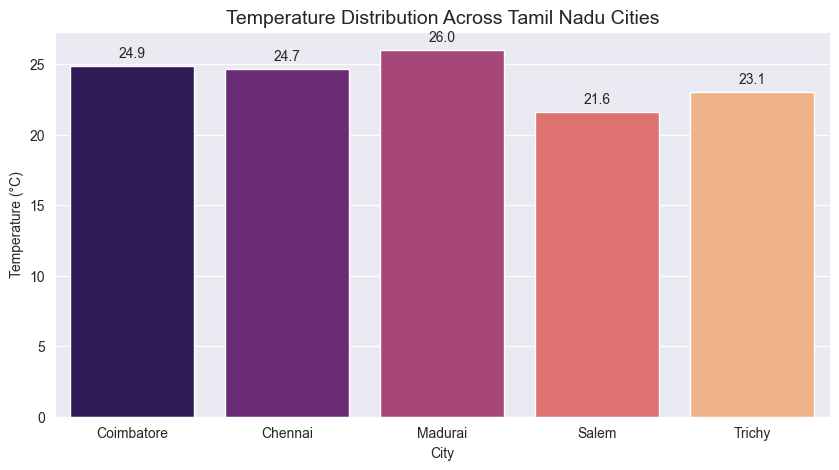

In [4]:
# Set the aesthetic style of the plots
sns.set_style("darkgrid")

plt.figure(figsize=(10, 5))
plot = sns.barplot(data=df, x="City", y="Temp", palette="magma")

# Adding labels for better "Dashboard" feel
plt.title("Temperature Distribution Across Tamil Nadu Cities", fontsize=14)
plt.ylabel("Temperature (°C)")
plt.xlabel("City")

# Adding the actual values on top of bars
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.1f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()